# Marketing Mix Modeling: Budget & ROI Optimization

In this project, I will build a **Machine Learning model to measure the impact of marketing investments on sales**. It involves **supervised learning (Regression)**, where the target is the **sales volume ($y$)** based on expenditures across various media channels **($X$)**.

I will use the following pipeline based on the **CRISP-DM framework**:

1. **Define the business problem.**
2. **Collect the data and get a general overview of it.**
3. **Split the data into train and test sets.**
4. **Explore the data (Exploratory Data Analysis).**
5. **Feature engineering and preprocessing (Adstock and Saturation).**
6. **Model training and hyperparameter tuning.**
7. **Model testing and evaluation.**
8. **Interpret results (ROI and Contribution).**
9. **Optimization Plan.**

---

In this notebook, I will perform **Exploratory Data Analysis (EDA)**, covering **steps 1 to 4 of the pipeline above**.

The main objective here is to **uncover insights into historical sales behavior** relative to the **investment channels used**, enabling a better understanding of how different media contributions impact overall performance.


# 1. Business problem

The central challenge is the **lack of visibility regarding the individual contribution of each sales channel** to the overall results. Without clear statistical modeling, investments are often distributed based on intuition, leading to **financial inefficiency** and **underutilization of channels with high scaling potential**.

## 1.1 What is the context?

In order to **optimize the marketing mix** and **maximize profitability**, three essential **Key Performance Indicators (KPIs)** are considered:

- **ROAS (Return on Ad Spend):** Measures the revenue generated for each monetary unit invested per channel. Higher ROAS reflects **efficient media spend**.

- **Sales Lift (Incrementality):** Represents the sales volume attributed exclusively to marketing efforts, isolating **organic growth** and **baseline sales**.

- **Marginal Acquisition Cost:** Measures the cost to generate the next sale in a specific channel, identifying **media saturation points**.

### Sales Channels Analyzed:

- **Digital:** Google Search (SEM), Social Media (Meta), and YouTube.

- **Offline:** TV (National/Regional) and Radio.

- **Support:** Email Marketing and Push Notifications.

## Which are the project objectives?

1. **Identify** the factors (channels) most associated with **revenue growth**.

2. **Construct** a model capable of accurately predicting **sales based on media plan changes**.

3. **Offer** action plans to **reallocate budget** from saturated channels to high-potential ones.

## Why the Marginal Contribution approach?

When deploying the model, the primary objective is to generate **contribution scores for each channel**. This is more valuable for business decision-making than simple total predictions, as it enables the company to understand **elasticity**.

This information allows for concentrating efforts on the **"sweet spot" of investment**, ordering channels from the **highest marginal return to the lowest**.

## Which are the benefits?

- **Cost Savings** by cutting spend on saturated media.

- **Improved Resource Allocation** based on **data-driven ROI**.

- **Enhanced Financial Predictability** for future sales cycles.

- **Targeted Budgeting** to protect **profit margins**.

## Importing Libraries

In [1]:
# Data manipulation and visualization.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import sys
import os

# Path Configuration to access src modules
sys.path.append(os.path.abspath(os.path.join('../')))

# Project Components
from src.utils import apply_corporate_style
from src.eda_utils import *

# Filter warnings.
import warnings
warnings.filterwarnings('ignore')

### Visualization Settings
%matplotlib inline
mpl.style.use('ggplot') 

mpl.rcParams['axes.facecolor']      = 'white'
mpl.rcParams['axes.linewidth']      = 1
mpl.rcParams['xtick.color']         = 'black'
mpl.rcParams['ytick.color']         = 'black'
mpl.rcParams['grid.color']          = 'lightgray'
mpl.rcParams['figure.dpi']          = 150
mpl.rcParams['axes.grid']           = True
mpl.rcParams['font.size']           = 12

# Palette Setting
color_palette = ['#023047', '#e85d04', '#0077b6', '#ff8200', '#0096c7', '#ff9c33']

# Setting as the palette
sns.set_palette(sns.color_palette(color_palette))

# Display Palette
print("✅ Project Environment Setup Complete.")
sns.color_palette(color_palette)

✅ Project Environment Setup Complete.


[(0.00784313725490196, 0.18823529411764706, 0.2784313725490196),
 (0.9098039215686274, 0.36470588235294116, 0.01568627450980392),
 (0.0, 0.4666666666666667, 0.7137254901960784),
 (1.0, 0.5098039215686274, 0.0),
 (0.0, 0.5882352941176471, 0.7803921568627451),
 (1.0, 0.611764705882353, 0.2)]

In [2]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

from src.components.data_ingestion import DataIngestion

ingestao = DataIngestion()
df_mmm = ingestao.initiate_data_ingestion()
df_mmm.head()

--- DEBUG DE TAMANHOS DAS COLUNAS ---
Coluna: Data | Tamanho: 156
Coluna: Vendas | Tamanho: 156
Coluna: Investimento_TV | Tamanho: 156
Coluna: Investimento_Google_Ads | Tamanho: 156
Coluna: Investimento_Facebook_Ads | Tamanho: 156
Coluna: Fator_Feriado | Tamanho: 156
Coluna: Fator_Sazonalidade | Tamanho: 156
-------------------------------------


,Vendas,Investimento_TV,Investimento_Google_Ads,Investimento_Facebook_Ads,Fator_Feriado,Fator_Sazonalidade
Data,,,,,,
2023-04-10,63.204967,17.777792,20.552446,19.720831,6.230423,4.976091
2023-04-17,67.406395,17.394508,20.412626,20.925434,3.964424,4.463735
2023-04-24,64.561142,19.735489,16.875376,21.928518,3.937733,7.598067
2023-05-01,63.577545,19.313116,20.446329,20.642603,5.775819,4.731113
2023-05-08,64.768959,18.865713,20.808935,21.666994,5.862508,5.124802


# CRISP-DM PHASE 2: DATA UNDERSTANDING
## Step 2.1: Data Collection & Overview

In [10]:
from src.eda_utils import gerar_dicionario_e_auditoria

df_mmm = pd.read_csv('artifacts/raw_data.csv', parse_dates=['Data'], index_col='Data')

display(gerar_dicionario_e_auditoria(df_mmm))

🕒 --- AUDITORIA DE CONTINUIDADE TEMPORAL ---
✅ Série temporal íntegra: 156 semanas consecutivas com espaçamento perfeito de 7 dias.

📊 --- DICIONÁRIO DE DADOS E TIPAGEM ---


,Tipo,Nulos (Qtd),Nulos (%),Valores Únicos,Exemplo (1ª Linha)
Vendas,float64,0,0.0,156,63.204967
Investimento_TV,float64,0,0.0,156,17.777792
Investimento_Google_Ads,float64,0,0.0,156,20.552446
Investimento_Facebook_Ads,float64,0,0.0,156,19.720830
Fator_Feriado,float64,0,0.0,156,6.230423
Fator_Sazonalidade,float64,0,0.0,156,4.976091


Alguns Insights:

* O dataset possui exatas 156 linhas. Como as datas começam em "2023-04-10" e "2023-04-17" (intervalos de 7 dias), temos dados agregados por semana. 156 semanas representam exatamente 3 anos de histórico.

* 0% Nulos: Não temos nenhum dado faltante (0 nulos).

Estrutura do Funil:

* Target (Variável Alvo): Vendas (O que queremos prever/otimizar).

* Features de Mídia (Variáveis de Decisão): Investimento_TV, Investimento_Google_Ads, Investimento_Facebook_Ads. Aqui aplicaremos curvas de saturação e Adstock mais para frente.

* Features de Controle (Fatores Exógenos): Fator_Feriado, Fator_Sazonalidade. Ótima arquitetura. O negócio já isolou efeitos de calendário.

ETAPA 2.3: ESTATÍSTICA DESCRITIVA CRÍTICA

In [11]:
# Avaliando a dispersão de mídia e vendas
display(analise_descritiva_mmm(df_mmm))

,mean,std,min,50%,max,assimetria (skew)
Vendas,65.61,3.82,57.07,65.21,74.34,0.20
Investimento_TV,19.91,1.70,14.76,19.86,24.11,0.03
Investimento_Google_Ads,20.07,1.57,16.88,20.11,24.60,0.30
Investimento_Facebook_Ads,20.12,1.60,16.24,19.92,24.37,0.19
Fator_Feriado,4.95,1.04,1.87,4.95,7.50,-0.15
Fator_Sazonalidade,4.92,1.07,2.46,5.00,7.60,-0.12


Anlguns insights: 

* As médias de investimento em TV (~19.91), Google (~20.07) e Facebook (~20.12) são quase idênticas. Isso indica uma estratégia de diversificação equilibrada, sem um canal dominante óbvio em termos de volume financeiro.

* O desvio padrão (std) é baixo em relação à média (~8%). Para um modelo de Marketing Mix Modeling, o excesso de estabilidade pode ser um problema, pois o modelo precisa de variabilidade (semanas com muito gasto vs. semanas com pouco) para aprender o que realmente traz vendas.

* Assimetria (Skewness) Controlada: * Google Ads (0.30): É o canal com maior assimetria positiva. Isso significa que há semanas específicas com "picos" de investimento maiores que a média. Esses pontos serão cruciais para medirmos a curva de saturação.

* TV (0.03): Distribuição quase perfeita. O investimento em TV é praticamente constante, o que pode dificultar a distinção entre o efeito da TV e o "Base Sales" (vendas orgânicas).

ETAPA 2.5: SÉRIE TEMPORAL

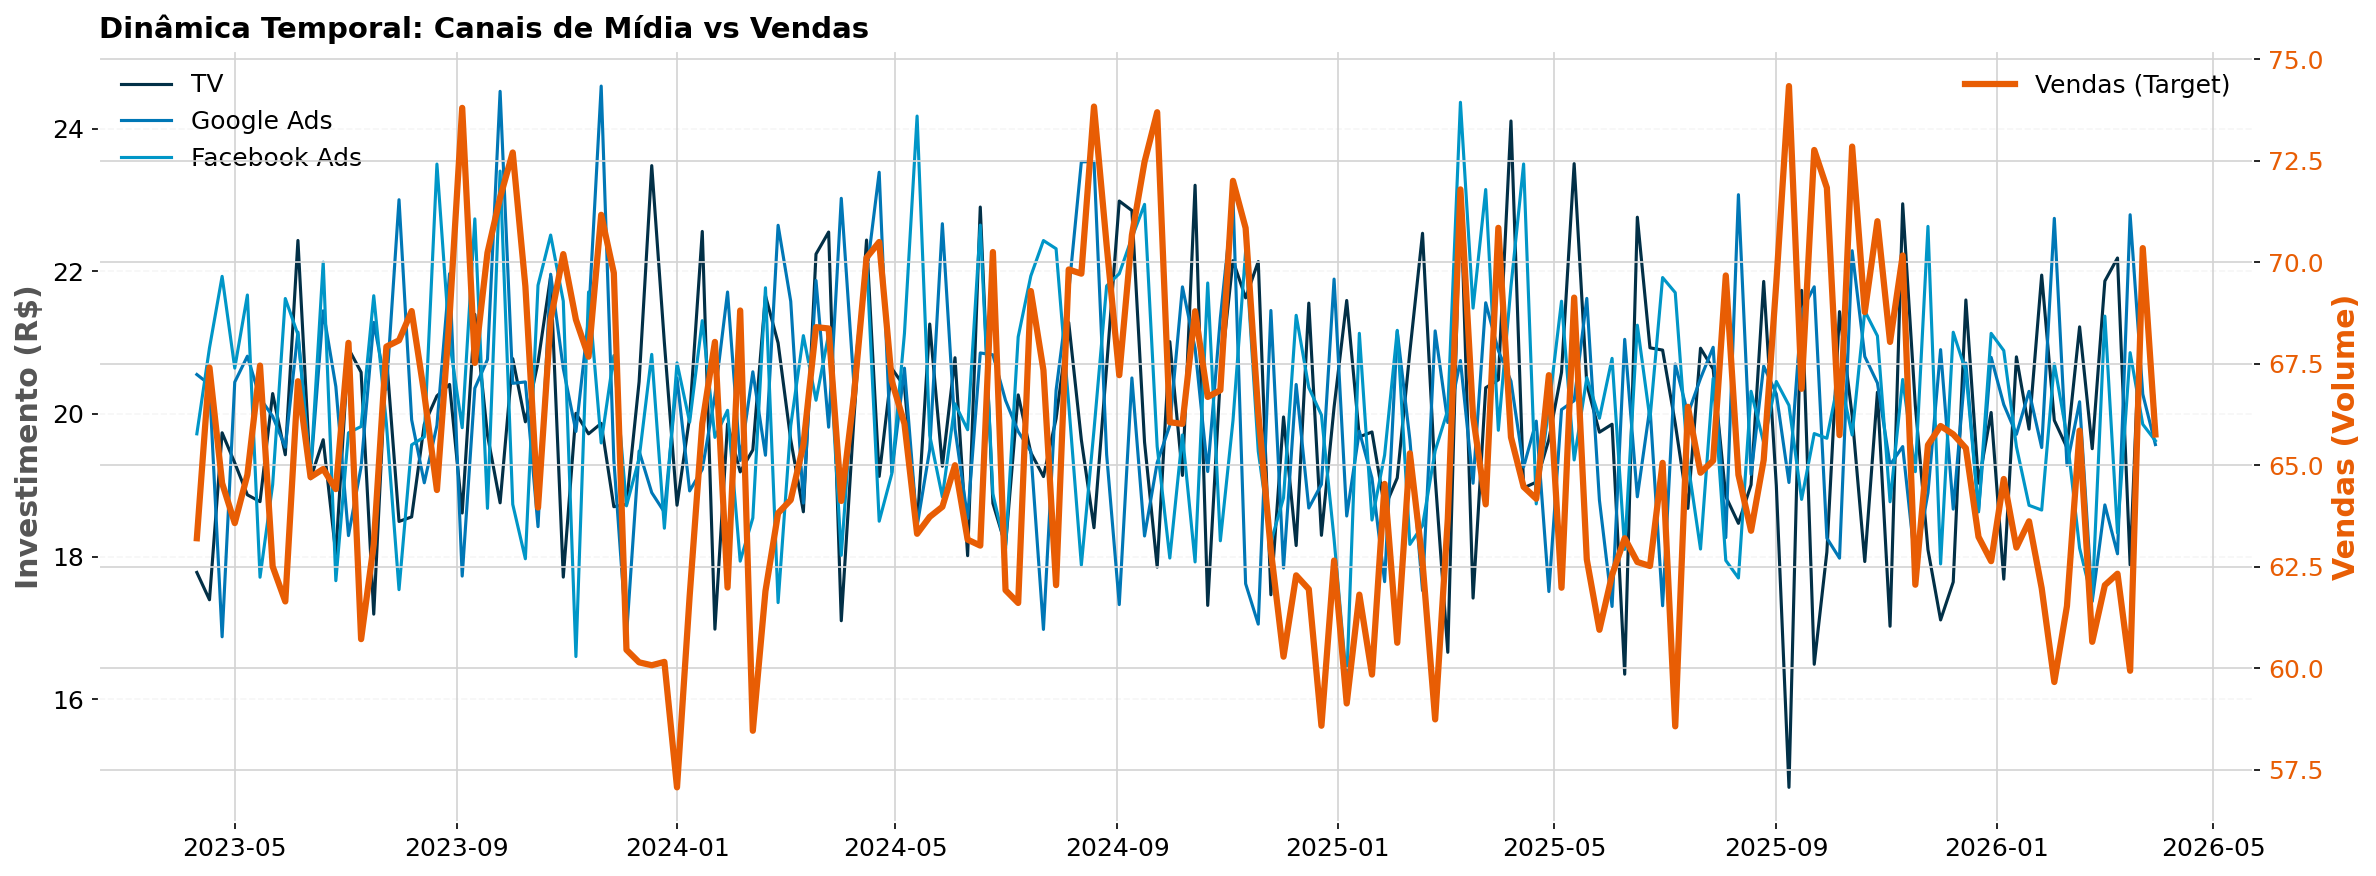

In [12]:
# Célula 1: Tendências Temporais com Cores Oficiais
plot_temporal_trends(df_mmm)

Insights da Dinâmica Temporal 

* Há uma alta volatilidade semanal tanto em mídia quanto em vendas. Isso é ótimo para o modelo, pois indica que os dados não são sintéticos demais.

* Ausência de Correlação Visual Óbvia: Nem todo pico de investimento (Azul) resulta em um pico imediato de Vendas (Laranja).

* O impacto da mídia não é apenas na semana do gasto. Precisaremos criar variáveis de "memória" para os canais.

* As vendas flutuam em uma faixa de 57 a 74, mesmo quando a mídia varia pouco. Existe um volume orgânico (Base) que o modelo precisará isolar.

* Identificamos um vale profundo em Vendas no início de 2024 que não foi acompanhado por uma queda drástica na mídia. Isso indica um fator externo que o Fator_Sazonalidade precisará explicar.

ETAPA 2.6: ANÁLISE DE OUTLIERS

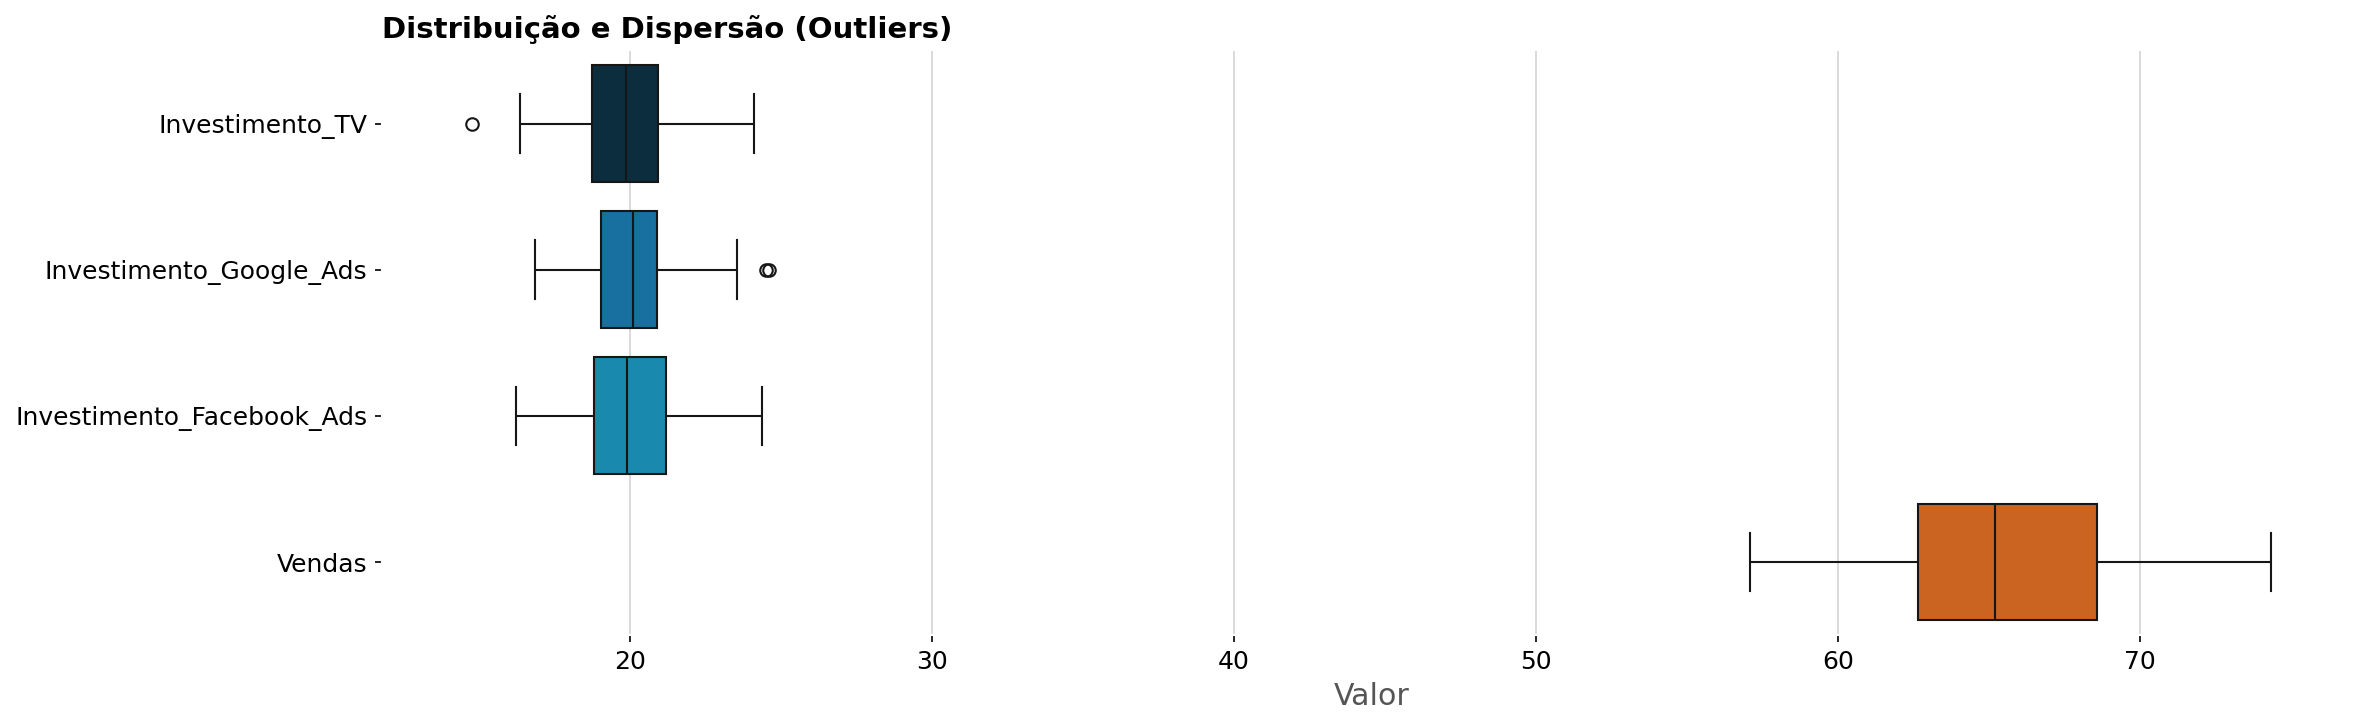

In [13]:
# Célula 2: Análise de Outliers com Cores Oficiais
plot_boxplots_marketing(df_mmm)

Insights da Distribuição (Boxplots)

* Outliers no Google Ads: Vemos pontos fora do bigode superior no Google Ads. São semanas de "Aggressive Bidding". Precisamos analisar se essas semanas geraram ROAS marginal positivo ou se apenas saturaram o canal.

* Estabilidade da TV. Para o MMM, isso é um desafio técnico, pois se o investimento não varia, o modelo pode ter dificuldade em atribuir o peso correto a ele.

ETAPA 2.7: CORRELAÇÃO E MULTICOLINEARIDADE

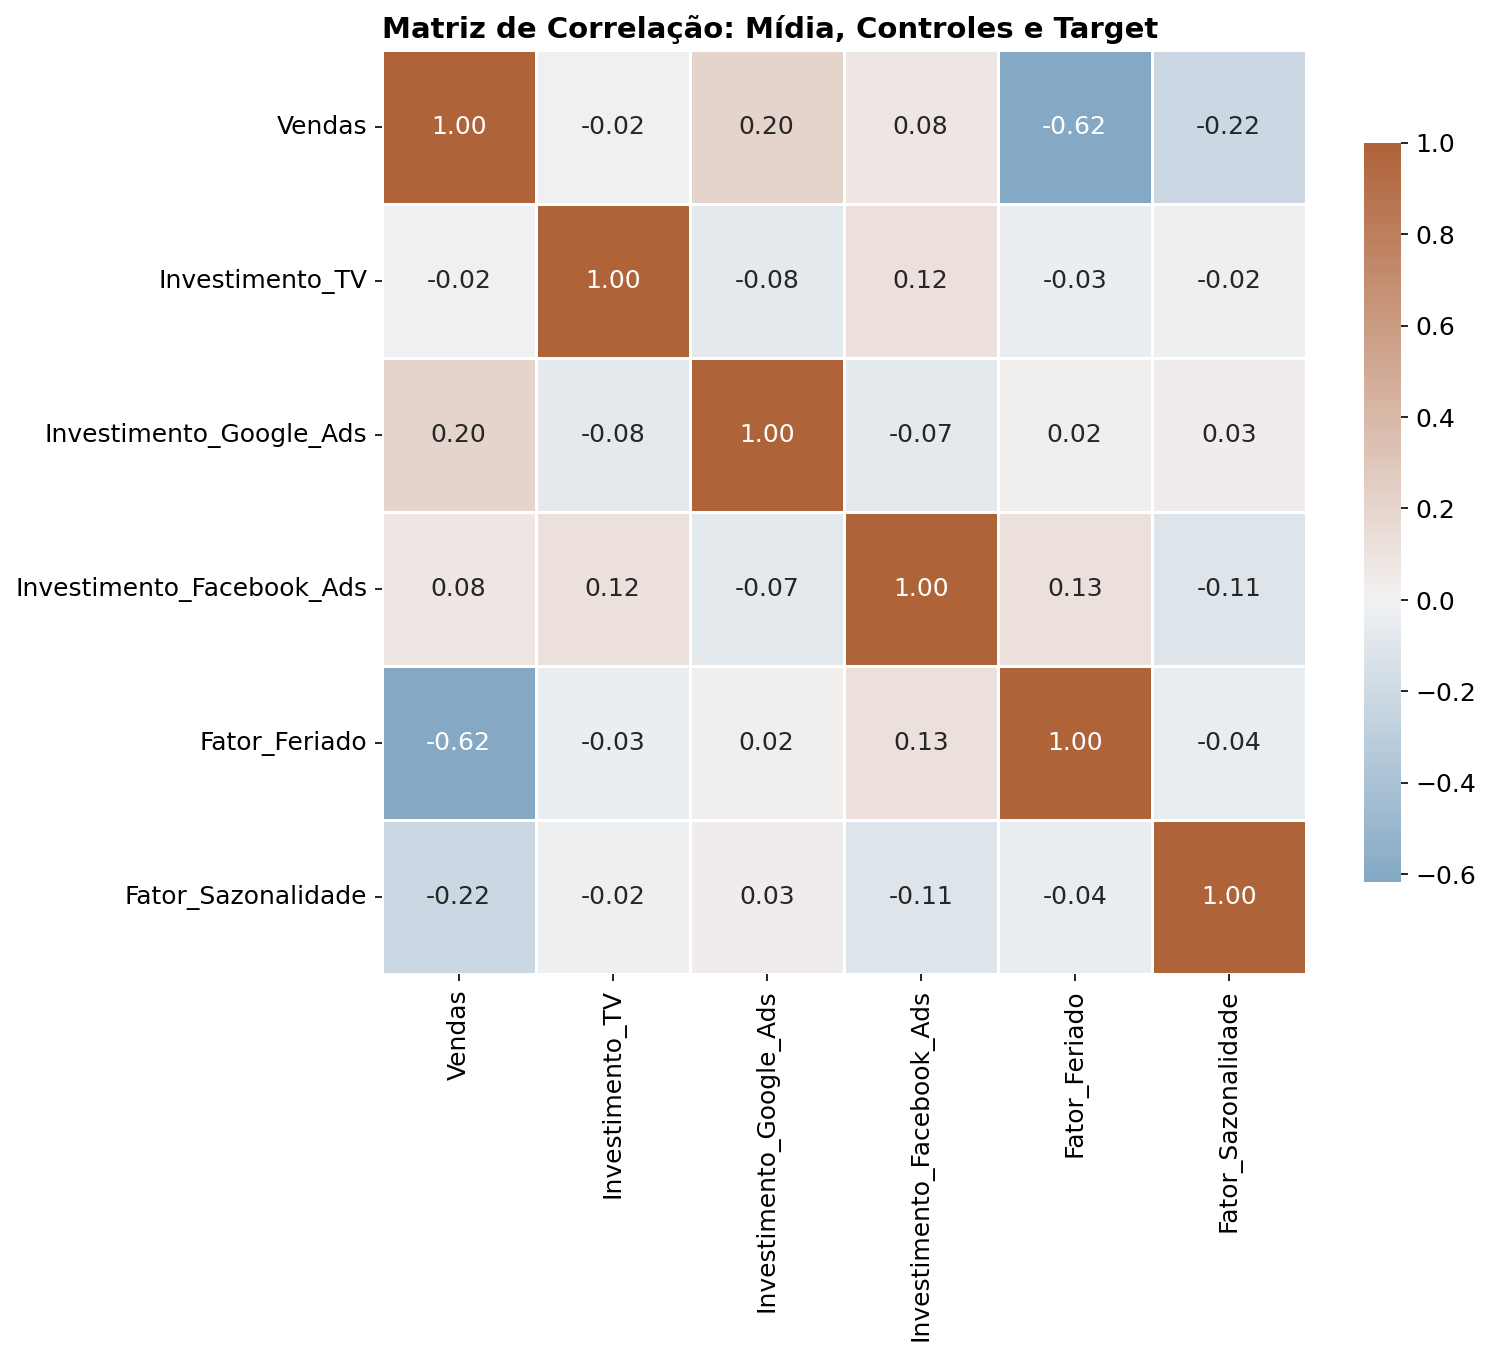

In [14]:
# Analisando a força estatística entre os canais
plot_correlation_heatmap(df_mmm)

INSIGHTS DA MATRIZ DE CORRELAÇÃO

* Analisando o Heatmap com a lente de Marketing Science, encontramos padrões reveladores e uma "bandeira vermelha" que precisamos investigar antes de modelar.

* Existe uma correlação negativa forte entre feriados e vendas. Isso significa que, estatisticamente, as vendas caem drasticamente em semanas de feriado.

* Correlação Imediata de Mídia é Baixa: Google (0.20), Facebook (0.08) e TV (-0.02) mostram quase nenhuma relação linear direta com as vendas da mesma semana.

* A mídia não é "clique e compre" imediato. Existe um efeito de Adstock (Carryover). O dinheiro investido hoje ecoa nas semanas seguintes. Ignorar isso na Fase 3 faria o modelo dizer que a TV é inútil, o que raramente é verdade.

* As correlações entre os canais (ex: TV vs Google) são baixíssimas.

ETAPA 2.8: ANÁLISE BIVARIADA E LAGGED CORRELATION

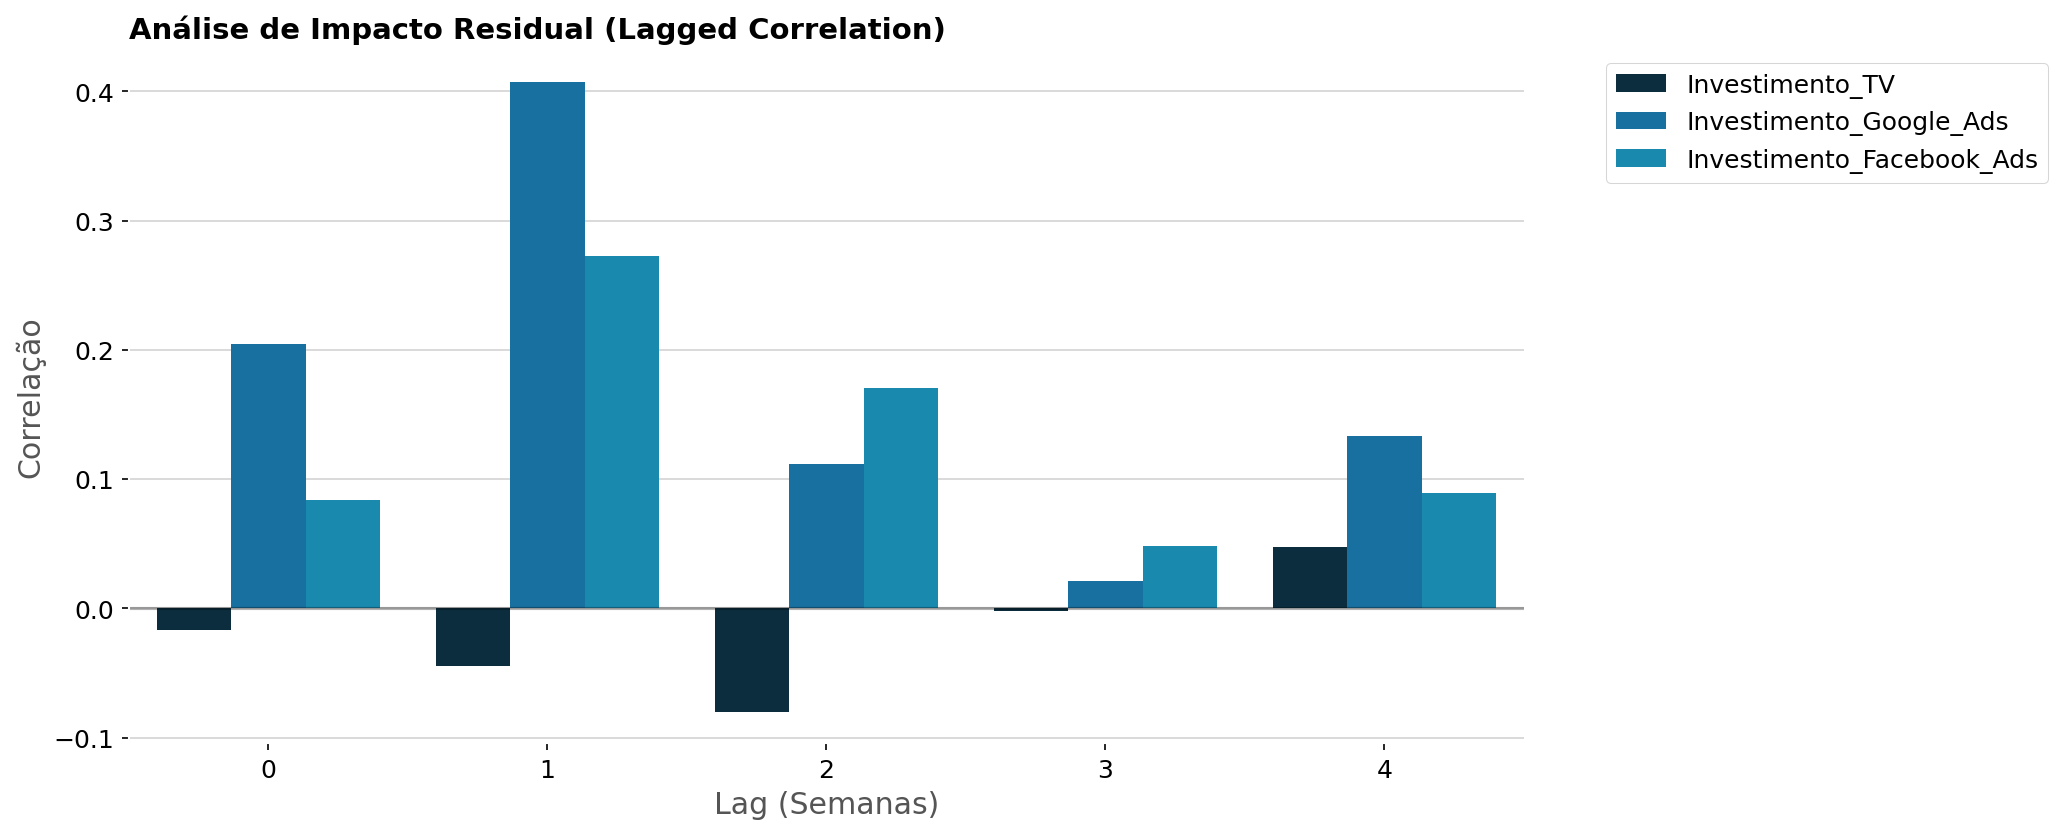

In [15]:
# Verificando se a mídia demora algumas semanas para "bater" na meta
plot_lagged_correlation(df_mmm)

1. O "Efeito Eco" (Adstock) Confirmado:

* Google e Facebook Ads: Repare que a correlação no Lag 1 é significativamente maior do que no Lag 0. O investimento que você faz hoje em digital demora cerca de 7 dias para atingir o pico de conversão.

* Ação Técnica: Na Fase 3 (Data Prep), seremos obrigados a criar colunas de Adstock para capturar esse carregamento de efeito, ou o modelo vai subestimar o ROAS desses canais.

* A TV continua apresentando correlação quase nula ou negativa em todos os lags próximos.

Hipótese: Ou a TV tem um ciclo de consideração muito mais longo (acima de 4 semanas), ou o investimento em TV está servindo apenas como Manutenção de Branding (não gerando picos, mas sustentando o volume base), ou os dados de TV precisam de uma transformação não-linear (Hill Function) para revelar seu valor.

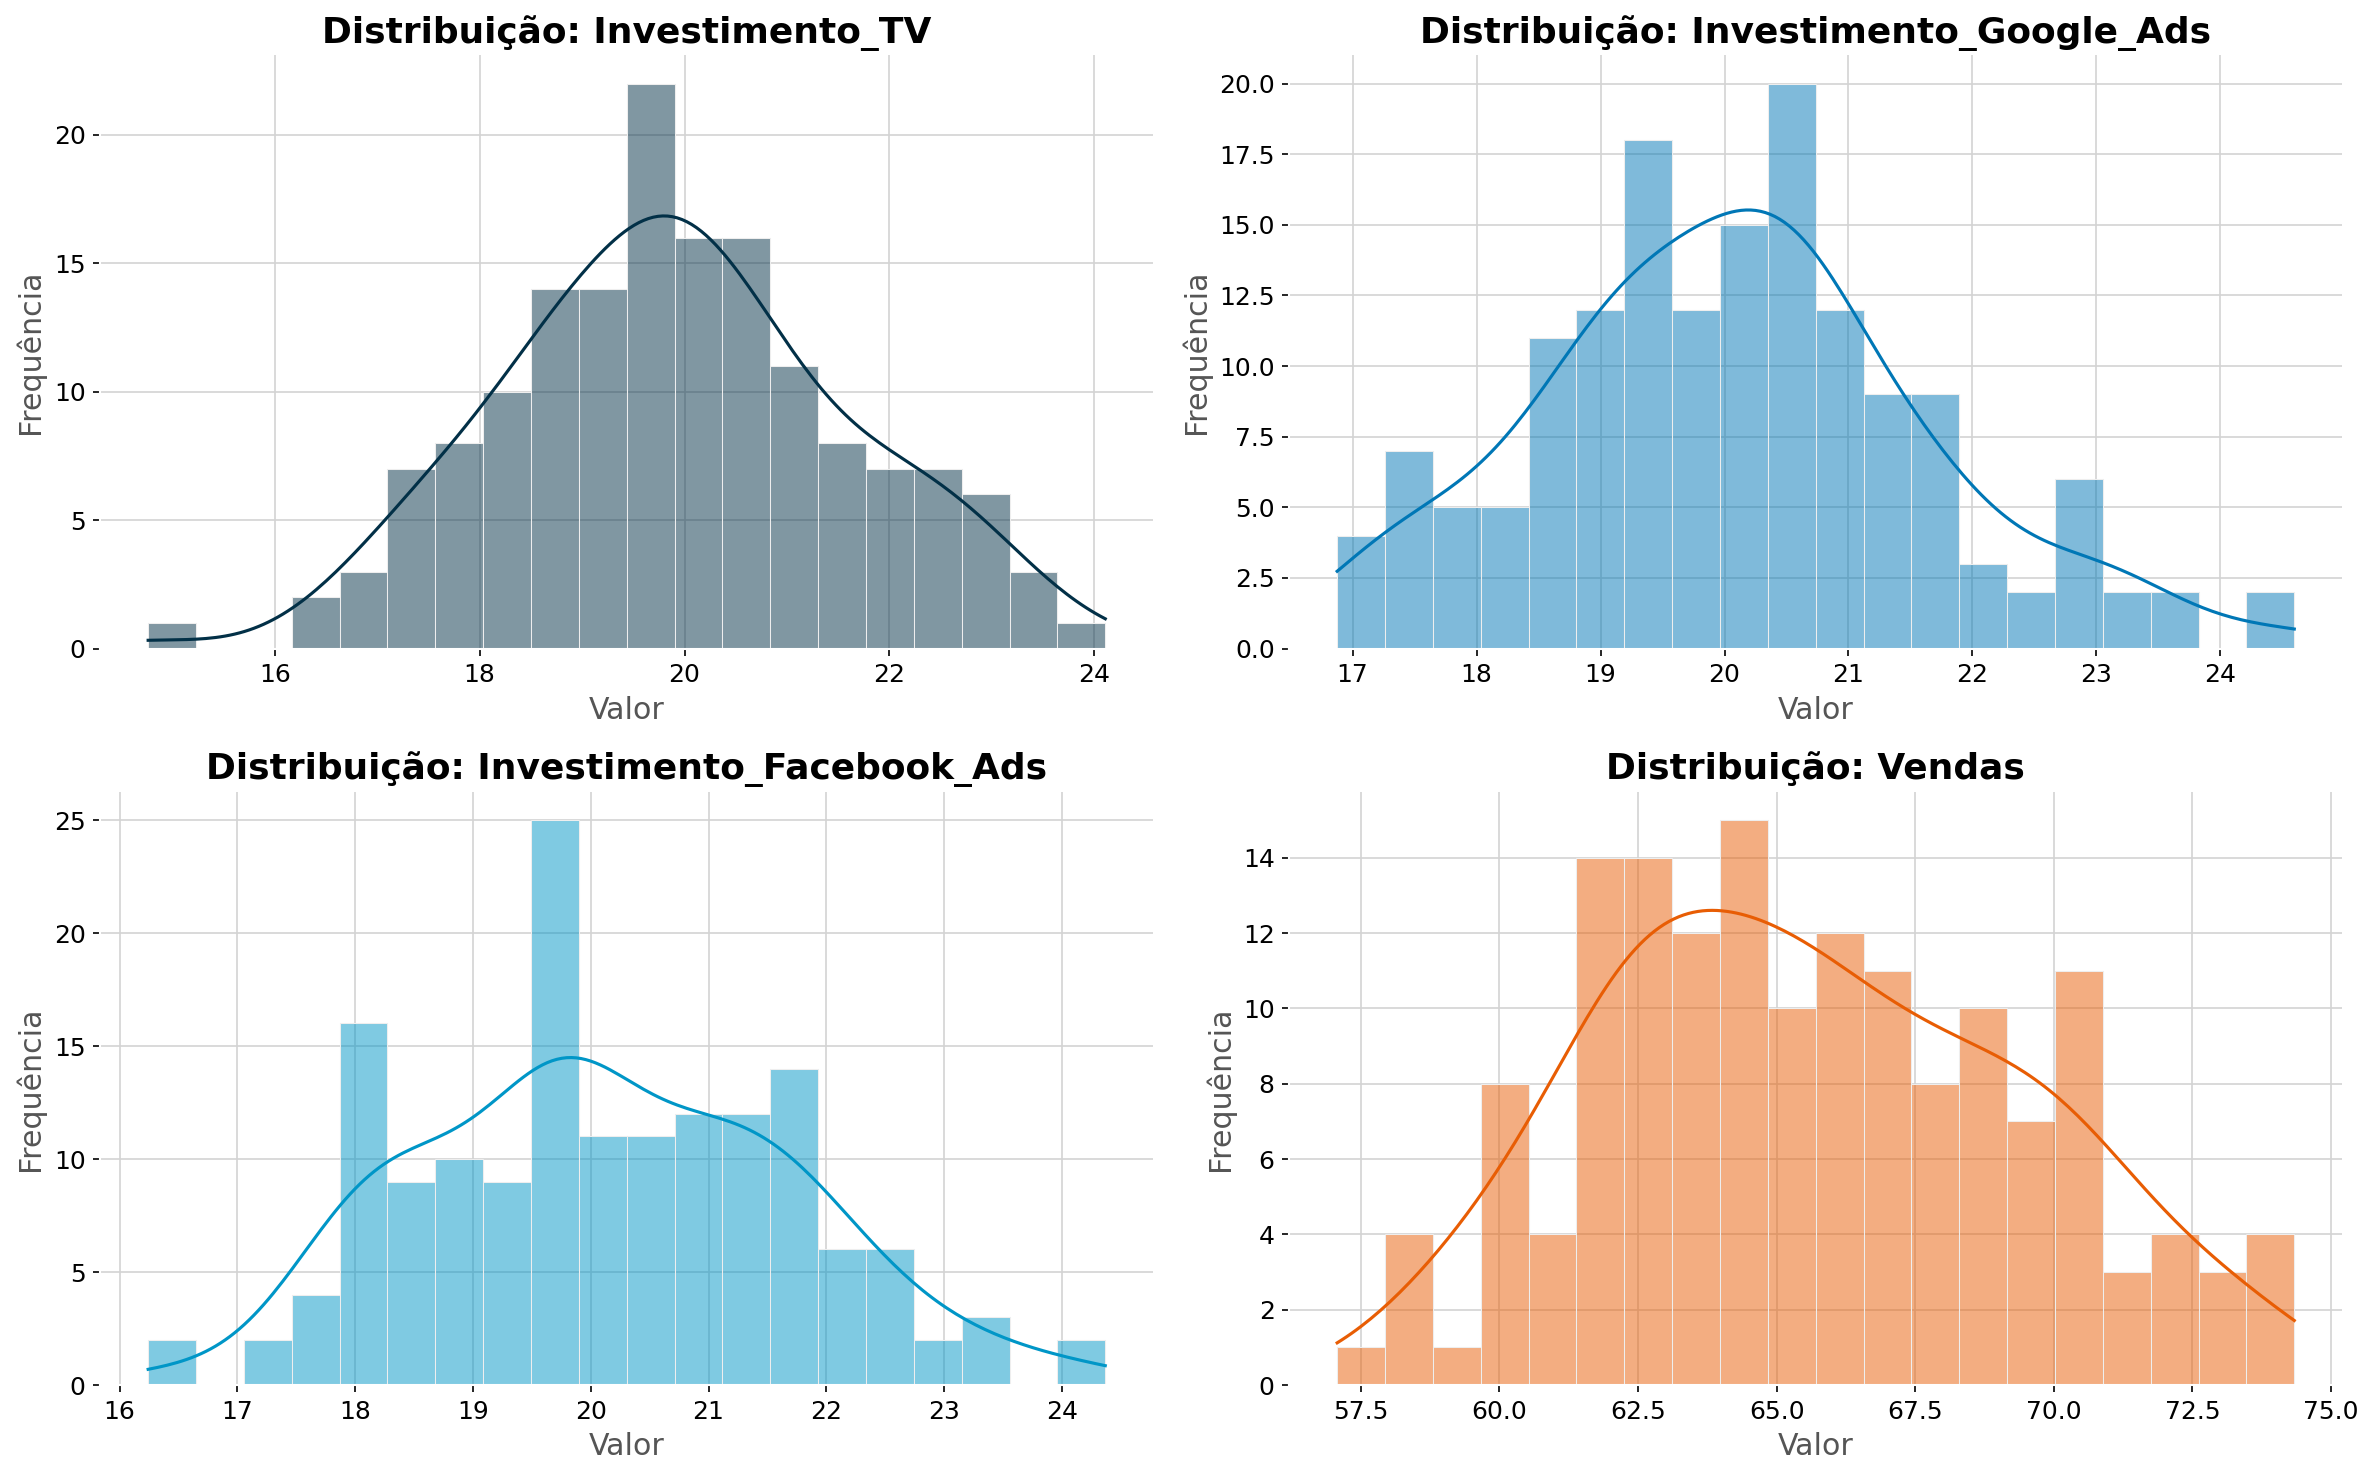

In [16]:
# 2.6.2 Análise de Distribuição das Features Numéricas
plot_numerical_distributions(df_mmm)

INSIGHTS DE DISTRIBUIÇÃO
* TV e Google Ads (Quase Gaussianas): As distribuições são bem comportadas e simétricas, centradas em torno de 20. 

* Facebook Ads (Comportamento Multimodal): o Facebook tem "picos" em 18, 20 e 22. Isso sugere um ajuste de orçamento por patamares. O algoritmo do Facebook performa de forma diferente em cada um desses níveis, e o modelo de MMM terá dados "agrupados" para aprender essas transições.

* Vendas (Assimetria à Direita): O target (Vendas) não é uma redoma perfeita. Ele tem uma cauda leve para a direita (valores entre 70-75). Como a mídia não tem essa mesma cauda, essas vendas extras provavelmente serão explicadas pelo seu Fator_Sazonalidade ou pelo Fator_Feriado.